## Modeling Stock Volatility using GARCH(1,1)
Author: Drew Glover

Date: March 31, 2026

### Objective: To model and forecast the volatility of AAPL stock using GARCH model.


#### Phase #1: Data Acquisition and Preparation: We will load the historial proce data for AAPL, calculate the daily log returns, and perform the preliminary analysis to confirm the presence of volatility clustering.


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Download the AAPL stock data from Jan 1, 2010 till today.

aapl_data = yf.download('AAPL', start='2010-01-01')

/tmp/ipython-input-2874267046.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl_data = yf.download('AAPL', start='2010-01-01')
[*********************100%***********************]  1 of 1 completed


In [3]:
aapl_data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.431896,6.446623,6.382908,6.414465,493729600
2010-01-05,6.443017,6.479382,6.409055,6.449629,601904800
2010-01-06,6.340531,6.468562,6.333919,6.443016,552160000
2010-01-07,6.328810,6.371488,6.282827,6.363974,477131200
2010-01-08,6.370885,6.371487,6.283128,6.320394,447610800


In [4]:
# Calculate daily logarithmic returns

aapl_data['log_return'] = np.log(aapl_data['Close'] / aapl_data['Close'].shift(1))

In [5]:
# Drop the NA values from first day's calculation
aapl_data = aapl_data.dropna()

In [6]:
# Visualise the plot

plt.figure(figsize=(15,6))

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

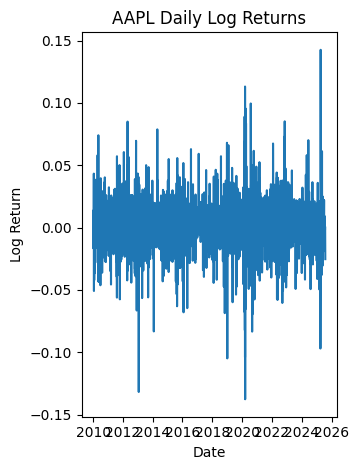

In [9]:
# Plot the daily close price

plt.subplot(1,2,2)
plt.plot(aapl_data['log_return'])
plt.title('AAPL Daily Log Returns')
plt.xlabel('Date')
plt.ylabel('Log Return')

# Display the plot
plt.tight_layout()
plt.show()

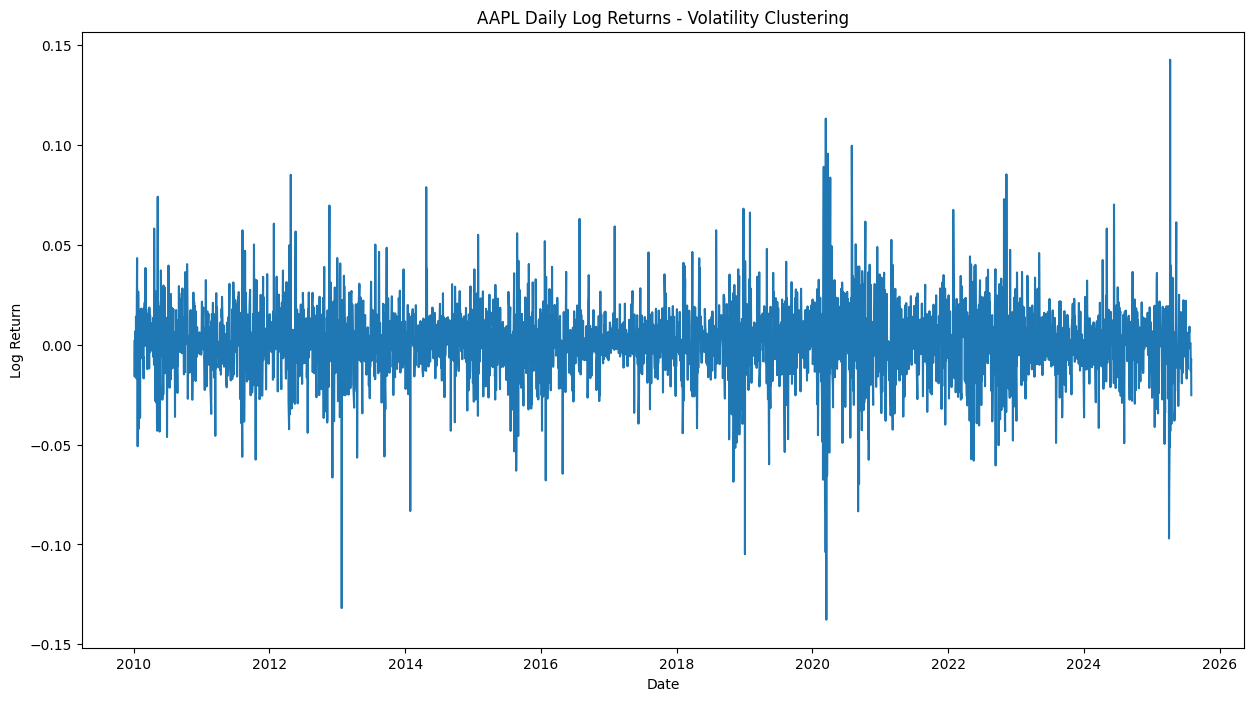

In [10]:
# plot the log return to see the clustering

plt.figure(figsize=(15,8))
plt.plot(aapl_data['log_return'])
plt.title('AAPL Daily Log Returns - Volatility Clustering')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.show()

### Statistical Tests:

We will perform statistical tests to confirm 2 kep properties of log-return series:

1. Stationarity: We will use the Augmented-Dickey-Fuller method to confirm that our return series is stationary.
2. ARCH Effects (Volatility Clustering): We will use Engle's ARCH test to statistically confirm the presence of volatility clustering.  

In [12]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_arch

In [14]:
# ADF Test: The time series models require that the data to be stationary - meaning its mean and variance are constant over time. using the Augmented-Dickey-Fuller Test.

# perform the adf test on log_return
adf_result = adfuller(aapl_data['log_return'])

In [18]:
print('ADF Statistic: %f' % adf_result[0])
print('p-value: %f' % adf_result[1])
print('Critical Values:')
for key, value in adf_result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -20.963805
p-value: 0.000000
Critical Values:
	1%: -3.432
	5%: -2.862
	10%: -2.567


Here, null hypothesis was the time series data is not stationary.
if the p-value is very small (less than 0.05), then we reject our null hypothesis and it proves that the time series data is indeed stationary.

In [22]:
# Volatility Clustering using Engle's ARCH Test:
# It tests for Autoregressive Conditional Heteroskedasticity (ARCH) effects.

arch_result = het_arch(aapl_data['log_return'])

print('\nARCH Tests:')
print('LM Statistic: %f' % arch_result[0])
print('p-value: %f' % arch_result[1])
print('F-value: %f' % arch_result[2])
print('F p-value: %f' % arch_result[3])


ARCH Tests:
LM Statistic: 393.679689
p-value: 0.000000
F-value: 43.654807
F p-value: 0.000000


Again the importance if of the p-value; it is less than 0.05, we reject the null hypothesis of there being no ARCH effects (no volatility clustering).
 It proves that the time series data has siginificant volatility clustering.

### Phase 2: GARCH Model Fitting
Having confirmed that our data is stationary and exhibits volatility clustering (ARCH effects), we can now proceed to fit a GARCH(1,1) model.

The GARCH(1,1) model is defined as:
**`σ²_t = ω + α * ε²_{t-1} + β * σ²_{t-1}`**

*   `ω (omega)`: The long-run average variance.
*   `α (alpha)`: The weight given to the previous period's squared shock/error.
*   `β (beta)`: The weight given to the previous period's conditional variance.

We will use the `arch` library in Python to estimate these parameters from our log-return data.

In [23]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.3/985.3 kB 45.4 MB/s eta 0:00:00


In [24]:
from arch import arch_model

In [26]:
# We will scale the log returns by 100 for better numerical stability during the optimisation process.

returns = aapl_data['log_return'] * 100

# p=1, q=1 specifies a GARCH(1,1) model.
# vol='Garch' specifies the GARCH variance model.
# dist='Normal' assumes the errors follow a normal distribution.
model = arch_model(returns, p=1, q=1, vol='Garch', dist='Normal')

In [28]:
# 2. Fit the model to the data.
# update_freq=5 shows the progress of the optimization every 5 iterations.
results = model.fit(update_freq=5)

Iteration:      5,   Func. Count:     33,   Neg. LLF: 1025035446.0071129
Iteration:     10,   Func. Count:     62,   Neg. LLF: 7511.367530878377
Optimization terminated successfully    (Exit mode 0)
            Current function value: 7511.367374045058
            Iterations: 13
            Function evaluations: 76
            Gradient evaluations: 13


In [29]:
# Display the model summary
print(results.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -7511.37
Distribution:                  Normal   AIC:                           15030.7
Method:            Maximum Likelihood   BIC:                           15055.8
                                        No. Observations:                 3918
Date:                Sun, Aug 03 2025   Df Residuals:                     3917
Time:                        12:45:14   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.1532  2.651e-02      5.776  7.630e-09 [  0.101,  0.20

## Model Evaluation and Forecasting:

We have to ensure that the model has correctly captured the model dynamics; we will then use the model to do the forecasting.

1. Residual Analysis: We will check the model's standardise residuals. If the model is a good fit then these residuals should be random noise with no remaining volatility clustering.
2. Forecasting: We will use this model to forecast the conditional volatility for the next 5 trading days.

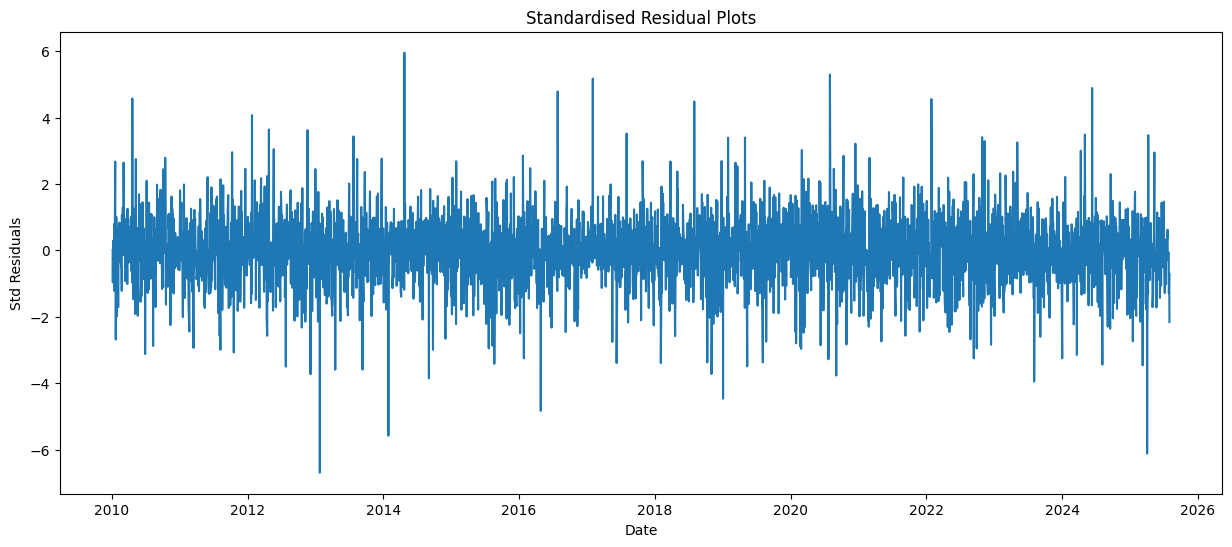

In [30]:
# plot the standardised residuals

plt.figure(figsize=(15,6))
plt.plot(results.std_resid)
plt.title('Standardised Residual Plots')
plt.xlabel('Date')
plt.ylabel('Std Residuals')
plt.show()

In [32]:
# Perform the ARCH test on the stadardised residuals

arch_test_res = het_arch(results.std_resid**2)

print('ARCH Test on Standardised Residuals:')
print('LM Statistic: %f' % arch_test_res[0])
print('p-Value: %f' % arch_test_res[1])

ARCH Test on Standardised Residuals:
LM Statistic: 1.680766
p-Value: 0.998253


Here, if the p-Value is greater than 0.05 we fail to reject the null hypothesis - model has successfully captured the volatility clustering and there are no significant ARCH effects left in the residue.

In [34]:
# Forecasting for the next 5 days.

forecast = results.forecast(horizon=5)

future_volatility = np.sqrt(forecast.variance.iloc[-1])/100

annual_volatility = future_volatility * np.sqrt(252)

print("\nForecasted Daily Volatility for the next 5 days:")
print(future_volatility)

print("\nForecasted Annualized Volatility for the next 5 days:")
print(annual_volatility)


Forecasted Daily Volatility for the next 5 days:
h.1    0.014892
h.2    0.015059
h.3    0.015216
h.4    0.015364
h.5    0.015503
Name: 2025-08-01 00:00:00, dtype: float64

Forecasted Annualized Volatility for the next 5 days:
h.1    0.236399
h.2    0.239057
h.3    0.241553
h.4    0.243898
h.5    0.246103
Name: 2025-08-01 00:00:00, dtype: float64
